In [2]:
import numpy as np
import xarray as xr
import cftime
import matplotlib as mpl
import matplotlib.pyplot as plt

In [3]:
import xarray as xr
from pathlib import Path
import sys
import os

analysis_path = os.path.abspath("../20260112_Basic_Analysis")
sys.path.append(analysis_path)

import myfunctions as mf

In [4]:
# Tropical bounds
trop_lat_min = -30
trop_lat_max = 30

In [5]:
# =========================
# User-defined metadata
# =========================

varname = "pr"

# =========================
# Base CEDA paths
# =========================

CEDA_BASE = Path("/badc/cmip6/data/CMIP6")

In [6]:
#Model Names
MODELS = {
    "UKESM1-0-LL":  {"institution": "MOHC",         "ensemble": "r1i1p1f2",  "grid": "gn",},
    "CNRM-ESM2-1":  {"institution": "CNRM-CERFACS", "ensemble": "r1i1p1f2",  "grid": "gr",},
    "MPI-ESM1-2-LR":{"institution": "MPI-M",        "ensemble": "r1i1p1f1",  "grid": "gn",},
    "CESM2-WACCM":  {"institution": "NCAR",         "ensemble": "r1i1p1f1",  "grid": "gn",},
    "IPSL-CM6A-LR": {"institution": "IPSL",         "ensemble": "r1i1p1f1",  "grid": "gr",},
}


In [7]:
#Experiment details
EXPERIMENTS = {
    # "HIST":     {"project": "CMIP",        "scenario": "historical", "color": "black"},
    "SSP245":   {"project": "ScenarioMIP", "scenario": "ssp245"},
    "SSP585":   {"project": "ScenarioMIP", "scenario": "ssp585"},
    "G6solar":  {"project": "GeoMIP",      "scenario": "G6solar"},
    "G6sulfur": {"project": "GeoMIP",      "scenario": "G6sulfur"},
}

# Calculating the contribution

In [10]:
counts_all = {}

for model_name, model_meta in MODELS.items():

    counts_all[model_name] = {}

    for exp, meta in EXPERIMENTS.items():

        if model_name == "CESM2-WACCM":
            ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
        else:
            ensemble = model_meta["ensemble"]

        base = (
            CEDA_BASE
            / meta["project"]
            / model_meta["institution"]
            / model_name
            / meta["scenario"]
            / ensemble
            / "day"
            / varname
            / model_meta["grid"]
            / "latest"
        )

        print(f"Reading {model_name} {exp}")
        ds = mf.open_files(str(base))
        da = mf.read_var(ds, varname)

        # --- PROCESS INSIDE EXP LOOP ---
        
        if model_name == "CESM2-WACCM":
            da = da.sel(
                time=slice(
                    cftime.DatetimeNoLeap(2071, 1, 1),
                    cftime.DatetimeNoLeap(2100, 12, 30)   # or the last date in your dataset
                )
            )
            da=da.load()
        else:
            da = da.sel(time=slice("2071-01-01", "2100-12")).load()

        # da = da.resample(time="1D").mean()*86400   # remove *86400 for tas

        da_tropics = da.sel(lat=slice(-15, 15))

        values = da_tropics.values.flatten()*86400
        values = values[np.isfinite(values)]

        bin_edges_ref = np.arange(0, 100, 2)

        counts, edges = np.histogram(values, bins=bin_edges_ref)
        percent = 100 * counts / counts.sum()
        
        # Precipitation contribution: sum of rainfall in each bin
        bin_centers = 0.5 * (edges[:-1] + edges[1:])
        precip_contrib, _ = np.histogram(values, bins=bin_edges_ref, weights=values)
        precip_percent = 100 * precip_contrib / precip_contrib.sum()
        
        # --- STORE ---
        counts_all[model_name][exp] = {
            "counts": counts,
            "percent": percent,
            "precip_contrib": precip_contrib,
            "precip_percent": precip_percent,
            "bin_edges": bin_edges_ref,
        }

Reading UKESM1-0-LL SSP245
Reading UKESM1-0-LL SSP585
Reading UKESM1-0-LL G6solar
Reading UKESM1-0-LL G6sulfur
Reading CNRM-ESM2-1 SSP245
Reading CNRM-ESM2-1 SSP585
Reading CNRM-ESM2-1 G6solar
Reading CNRM-ESM2-1 G6sulfur
Reading MPI-ESM1-2-LR SSP245
Reading MPI-ESM1-2-LR SSP585
Reading MPI-ESM1-2-LR G6solar
Reading MPI-ESM1-2-LR G6sulfur
Reading CESM2-WACCM SSP245
Reading CESM2-WACCM SSP585
Reading CESM2-WACCM G6solar
Reading CESM2-WACCM G6sulfur
Reading IPSL-CM6A-LR SSP245
Reading IPSL-CM6A-LR SSP585
Reading IPSL-CM6A-LR G6solar
Reading IPSL-CM6A-LR G6sulfur


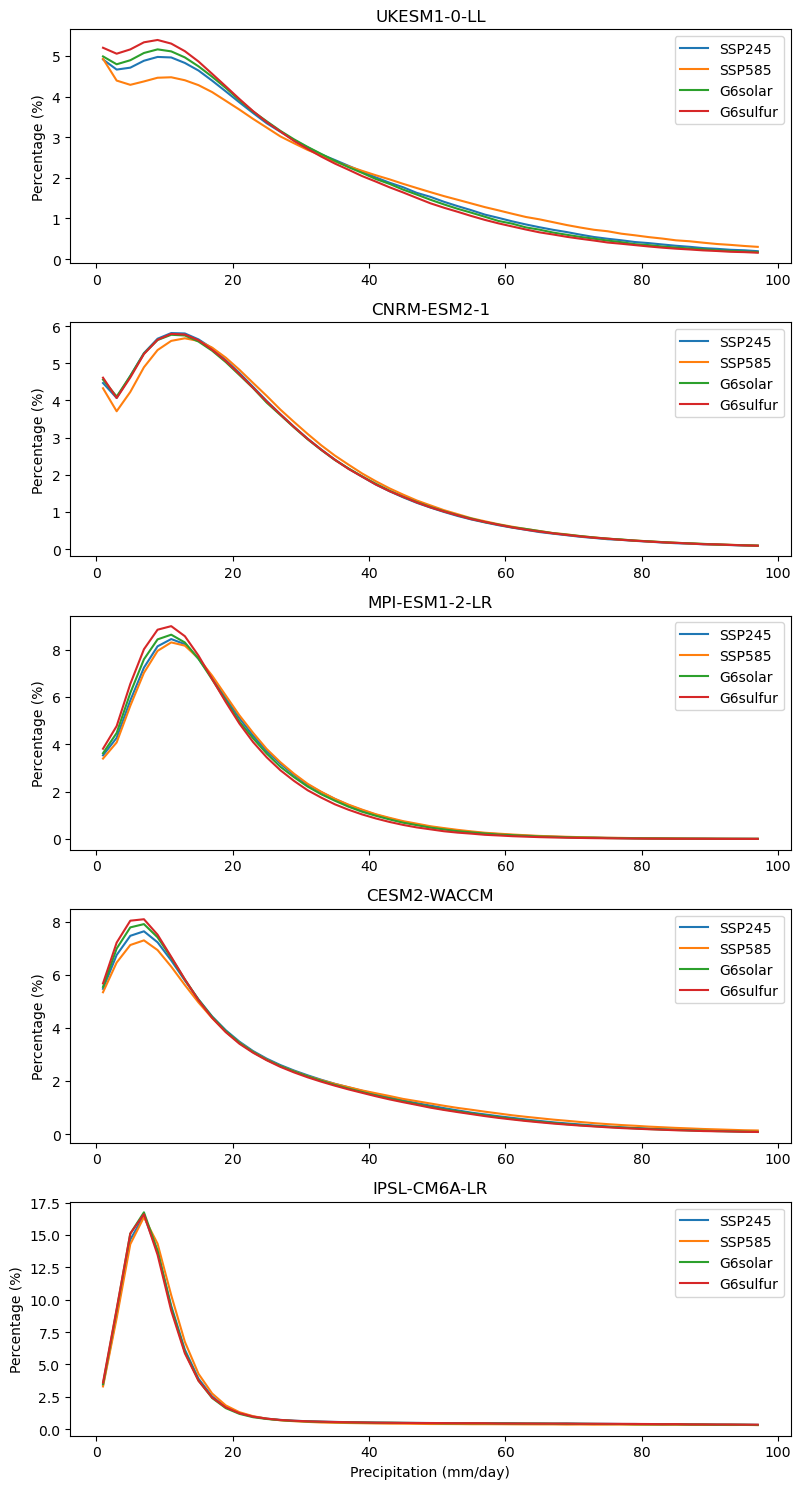

In [11]:
fig, axes = plt.subplots(
    nrows=len(counts_all),
    ncols=1,
    figsize=(8, 3 * len(counts_all)),
)

axes = np.atleast_1d(axes)

for row, model in enumerate(counts_all):

    for exp in counts_all[model]:

        percent = counts_all[model][exp]["precip_percent"]
        edges = counts_all[model][exp]["bin_edges"]
        centers = 0.5 * (edges[:-1] + edges[1:])

        axes[row].plot(centers, percent, label=exp)

    axes[row].set_title(model)
    axes[-1].set_xlabel("Precipitation (mm/day)")
    axes[row].set_ylabel("Percentage (%)")
    axes[row].legend()

plt.tight_layout()
#Saving figure
# fig_directory='/home/users/bidyut/UoE/20260112_Basic_Analysis'
# figname="Figure_PDF_PR_2071-2100"

# plt.savefig(''+str(fig_directory)+'/'+str(figname)+'.svg', format="svg",transparent=True, dpi=1200)
# !rsvg-convert -f pdf -o {fig_directory}/{figname}.pdf {fig_directory}/{figname}.svg

# plt.savefig(''+str(fig_directory)+'/'+str(figname)+'.pdf', format="pdf")

plt.show()

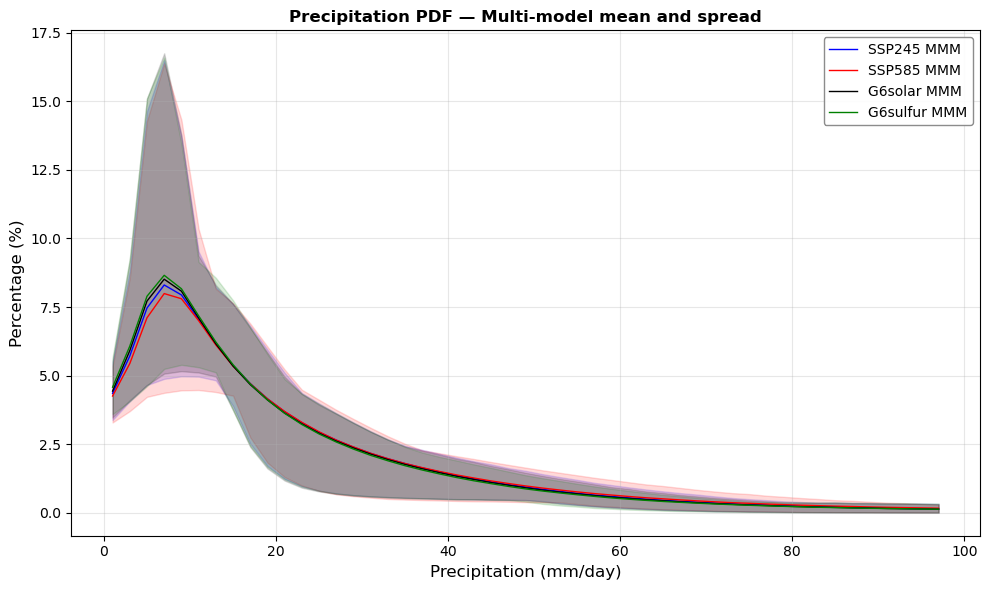

In [27]:
# ================================================================
# PLOT precipitation PDF - individual models + MMM + spread
# ================================================================

# --- Build common bin centers from first model/exp ---
first_model = next(iter(counts_all))
first_exp   = next(iter(counts_all[first_model]))
edges       = counts_all[first_model][first_exp]['bin_edges']
centers     = 0.5 * (edges[:-1] + edges[1:])

# --- Collect per-experiment data across models ---
all_exps = list(next(iter(counts_all.values())).keys())  # e.g. ['SSP245', 'G6sulfur']
exp_colors = {'SSP245': 'blue', 'G6sulfur': 'green', 'SSP585': 'red', 'G6solar': 'black'}  # adjust as needed

fig, ax = plt.subplots(figsize=(10, 6))

for exp in all_exps:
    color = exp_colors.get(exp, None)

    # Stack percent arrays across models → (n_models, n_bins)
    stacked = np.vstack([
        counts_all[model][exp]['precip_percent']
        for model in counts_all
        if exp in counts_all[model]
    ])

    mmm       = np.nanmean(stacked, axis=0)
    spread_lo = np.nanmin(stacked,  axis=0)
    spread_hi = np.nanmax(stacked,  axis=0)

    # # Individual model lines (thin, transparent)
    # for i, model in enumerate(counts_all):
    #     if exp not in counts_all[model]:
    #         continue
    #     ax.plot(centers, counts_all[model][exp]['precip_percent'],
    #             color=color, linewidth=0.8, alpha=0.25, label='_nolegend_')

    # Spread (min-max)
    ax.fill_between(centers, spread_lo, spread_hi,
                    color=color, alpha=0.15, label='_nolegend_') #f'{exp} spread (min–max)')

    # Multi-model mean
    ax.plot(centers, mmm,
            color=color, linewidth=1, label=f'{exp} MMM')

ax.set_xlabel('Precipitation (mm/day)', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Precipitation PDF — Multi-model mean and spread', 
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, framealpha=0.9, edgecolor='gray')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

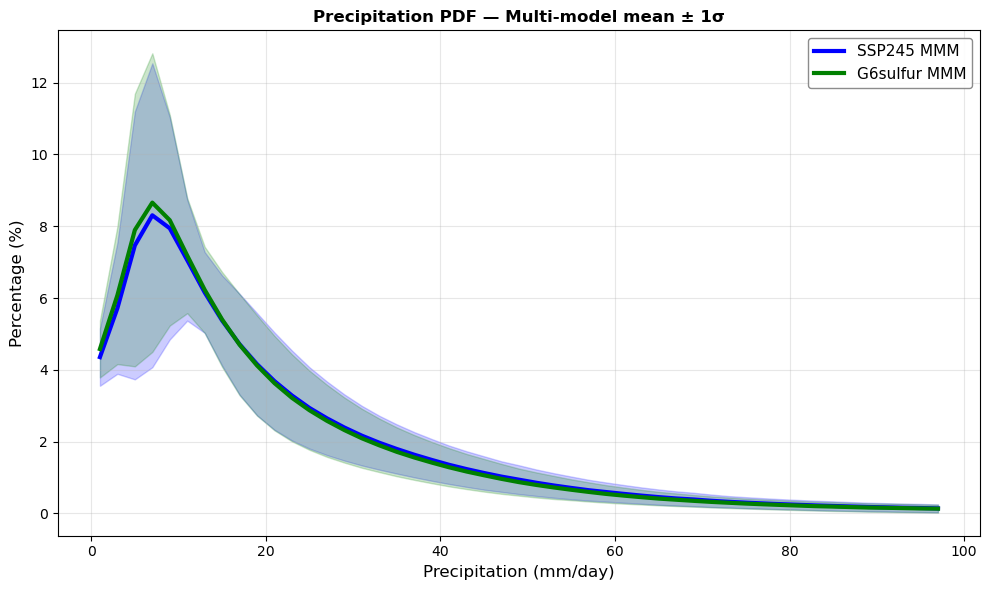

In [30]:
# ================================================================
# PLOT precipitation PDF - MMM + ±1 std spread
# ================================================================

first_model = next(iter(counts_all))
first_exp   = next(iter(counts_all[first_model]))
edges       = counts_all[first_model][first_exp]['bin_edges']
centers     = 0.5 * (edges[:-1] + edges[1:])

# all_exps   = list(next(iter(counts_all.values())).keys())
all_exps = ['SSP245', 'G6sulfur']
exp_colors = {'SSP245': 'blue', 'G6sulfur': 'green', 'SSP585': 'red', 'G6solar': 'black'}  # adjust as needed

fig, ax = plt.subplots(figsize=(10, 6))

for exp in all_exps:
    color = exp_colors.get(exp, 'black')

    stacked = np.vstack([
        counts_all[model][exp]['precip_percent']
        for model in counts_all
        if exp in counts_all[model]
    ])

    mmm = np.nanmean(stacked, axis=0)
    std = np.nanstd(stacked,  axis=0)

    # ±1 std shading
    ax.fill_between(centers, mmm - std, mmm + std,
                    color=color, alpha=0.2, label='_nolegend_')

    # MMM line
    ax.plot(centers, mmm,
            color=color, linewidth=3, label=f'{exp} MMM')

ax.set_xlabel('Precipitation (mm/day)', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Precipitation PDF — Multi-model mean ± 1σ',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11, framealpha=0.9, edgecolor='gray')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

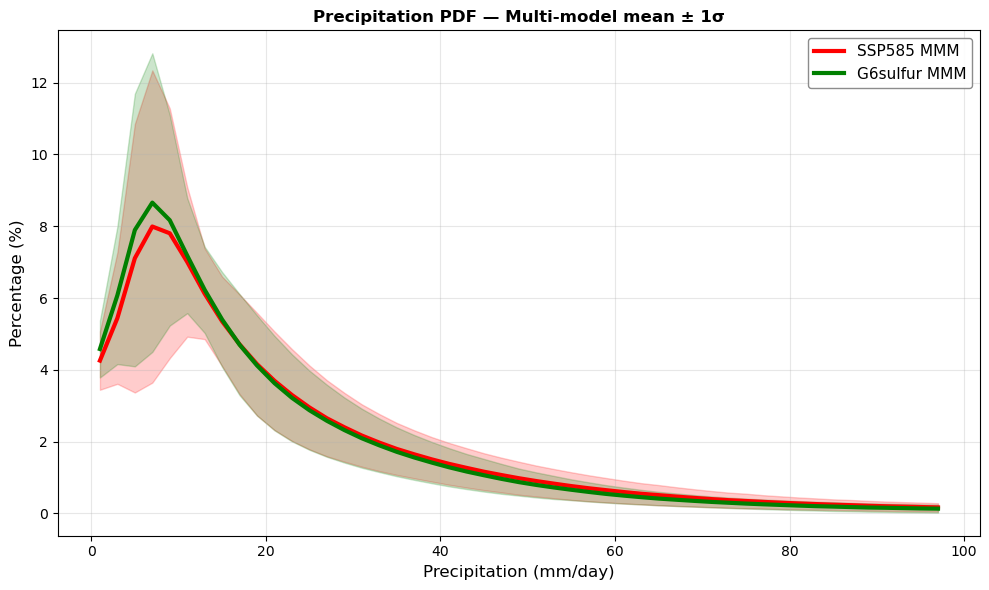

In [31]:
# ================================================================
# PLOT precipitation PDF - MMM + ±1 std spread
# ================================================================

first_model = next(iter(counts_all))
first_exp   = next(iter(counts_all[first_model]))
edges       = counts_all[first_model][first_exp]['bin_edges']
centers     = 0.5 * (edges[:-1] + edges[1:])

# all_exps   = list(next(iter(counts_all.values())).keys())
all_exps = ['SSP585', 'G6sulfur']
exp_colors = {'SSP245': 'blue', 'G6sulfur': 'green', 'SSP585': 'red', 'G6solar': 'black'}  # adjust as needed

fig, ax = plt.subplots(figsize=(10, 6))

for exp in all_exps:
    color = exp_colors.get(exp, 'black')

    stacked = np.vstack([
        counts_all[model][exp]['precip_percent']
        for model in counts_all
        if exp in counts_all[model]
    ])

    mmm = np.nanmean(stacked, axis=0)
    std = np.nanstd(stacked,  axis=0)

    # ±1 std shading
    ax.fill_between(centers, mmm - std, mmm + std,
                    color=color, alpha=0.2, label='_nolegend_')

    # MMM line
    ax.plot(centers, mmm,
            color=color, linewidth=3, label=f'{exp} MMM')

ax.set_xlabel('Precipitation (mm/day)', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Precipitation PDF — Multi-model mean ± 1σ',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11, framealpha=0.9, edgecolor='gray')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [41]:
def plot_pdf_diff(counts_all, exp1, exp2, exp_colors=None, title=None):
    """
    Plot the difference in precipitation PDF MMM between two experiments.
    Difference is computed as exp1 - exp2.
    
    Parameters
    ----------
    counts_all  : dict  - {model: {exp: {'precip_percent', 'bin_edges'}}}
    exp1        : str   - experiment to subtract from (minuend)
    exp2        : str   - experiment to subtract (subtrahend)
    exp_colors  : dict  - optional {exp: color} for the difference line
    title       : str   - optional plot title override
    """
    if exp_colors is None:
        exp_colors = {
            'SSP245':  'blue',
            'G6sulfur':'green',
            'SSP585':  'red',
            'G6solar': 'black',
        }

    # --- Common bin centers ---
    first_model = next(iter(counts_all))
    edges   = counts_all[first_model][exp1]['bin_edges']
    centers = 0.5 * (edges[:-1] + edges[1:])

    # --- Stack across models ---
    stacked1 = np.vstack([
        counts_all[model][exp1]['precip_percent']
        for model in counts_all
        if exp1 in counts_all[model]
    ])
    stacked2 = np.vstack([
        counts_all[model][exp2]['precip_percent']
        for model in counts_all
        if exp2 in counts_all[model]
    ])

    mmm1 = np.nanmean(stacked1, axis=0)
    mmm2 = np.nanmean(stacked2, axis=0)

    # --- Per-model difference for spread ---
    # Only use models that have both experiments
    models_both = [m for m in counts_all
                   if exp1 in counts_all[m] and exp2 in counts_all[m]]
    diff_stack = np.vstack([
        counts_all[m][exp1]['precip_percent'] - counts_all[m][exp2]['precip_percent']
        for m in models_both
    ])

    mmm_diff = np.nanmean(diff_stack, axis=0)
    std_diff = np.nanstd(diff_stack,  axis=0)

    # --- Plot ---
    color = exp_colors.get(exp1, 'black')

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.fill_between(centers, mmm_diff - std_diff, mmm_diff + std_diff,
                    color=color, alpha=0.2, label='±1σ across models')

    ax.plot(centers, mmm_diff,
            color=color, linewidth=3, label=f'MMM  {exp1} − {exp2}')

    ax.axhline(0, color='gray', linestyle='--', linewidth=1)

    ax.set_xlabel('Precipitation (mm/day)', fontsize=12)
    ax.set_ylabel('Difference in percentage (pp)', fontsize=12)
    ax.set_title(title or f'Precipitation (Daily) PDF difference — {exp1} minus {exp2}\n'
                           f'Multi-model mean ± 1σ  (n={len(models_both)} models)',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=11, framealpha=0.9, edgecolor='gray')
    ax.grid(True, alpha=0.3)
    # ax.set_ylim(-0.7,0.7)

    plt.tight_layout()
    plt.show()

    return mmm_diff, std_diff, centers

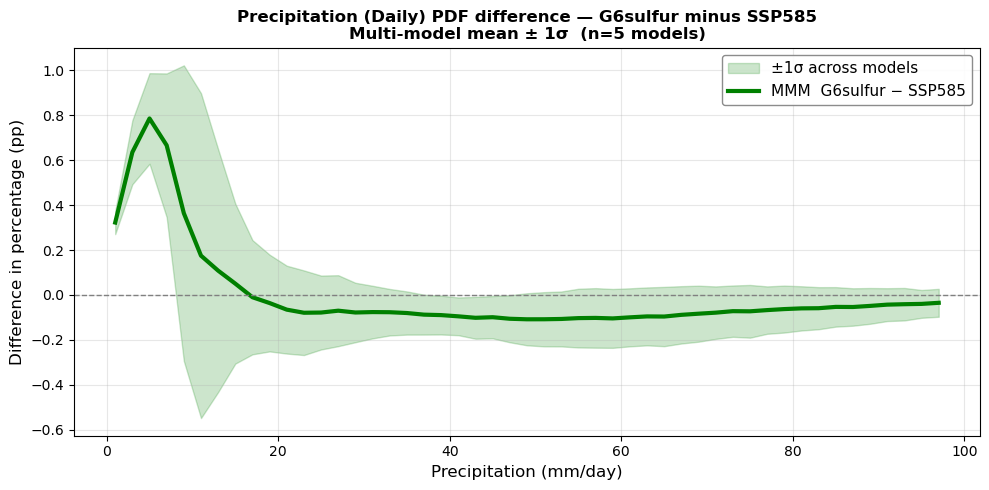

In [42]:
# --- Example usage ---
mmm_diff, std_diff, centers = plot_pdf_diff(counts_all, exp1='G6sulfur', exp2='SSP585')

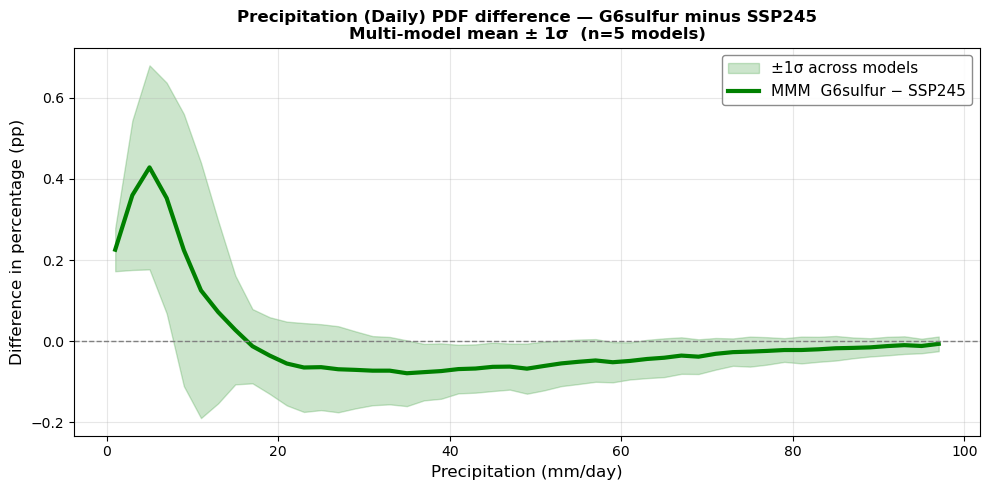

In [43]:
# --- Example usage ---
mmm_diff, std_diff, centers = plot_pdf_diff(counts_all, exp1='G6sulfur', exp2='SSP245')

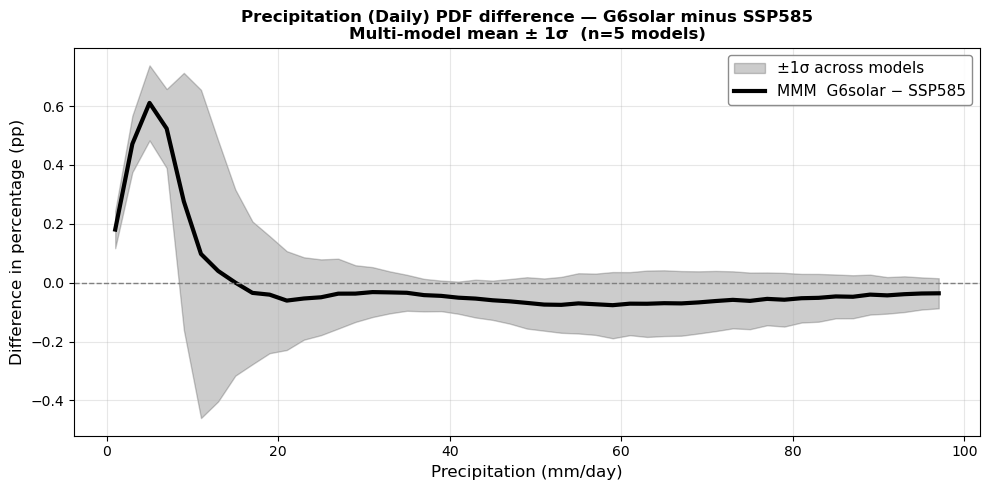

In [44]:
# --- Example usage ---
mmm_diff, std_diff, centers = plot_pdf_diff(counts_all, exp1='G6solar', exp2='SSP585')

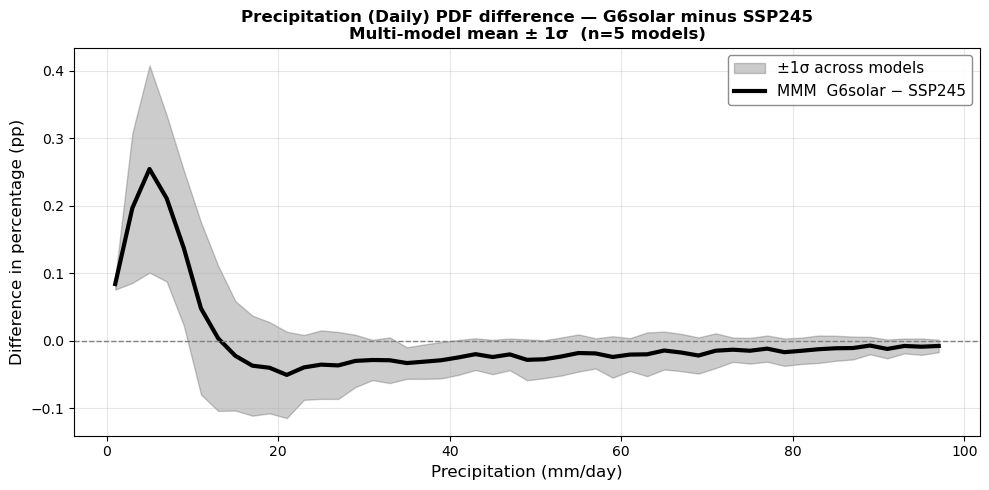

In [45]:
mmm_diff, std_diff, centers = plot_pdf_diff(counts_all, exp1='G6solar', exp2='SSP245')

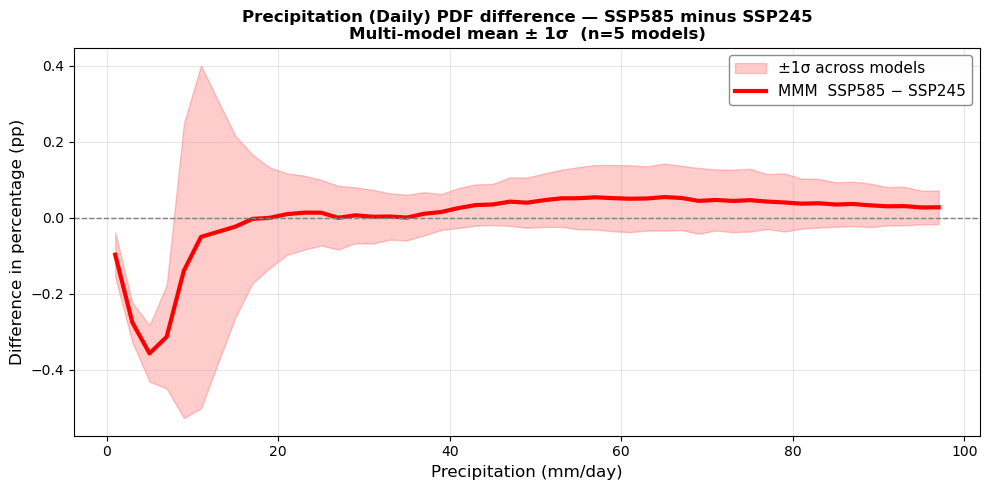

In [46]:
mmm_diff, std_diff, centers = plot_pdf_diff(counts_all, exp1='SSP585', exp2='SSP245')

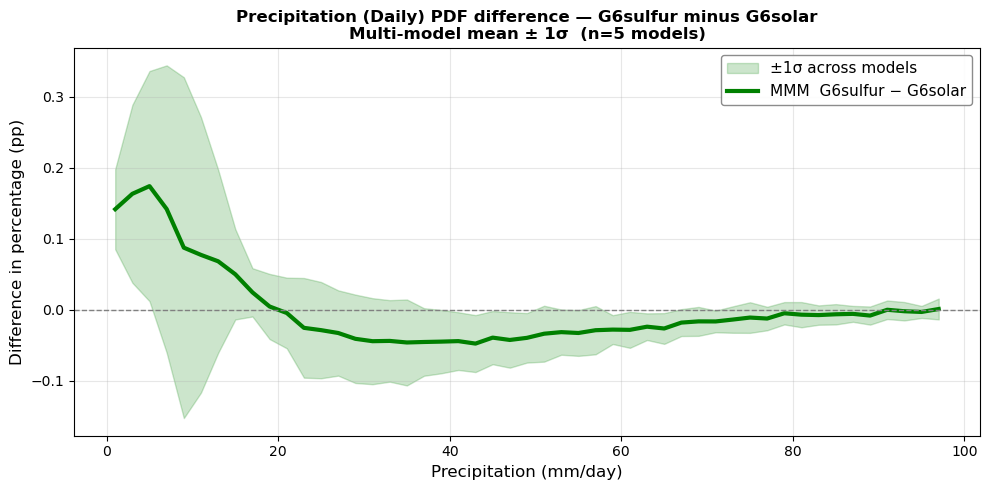

In [47]:
mmm_diff, std_diff, centers = plot_pdf_diff(counts_all, exp1='G6sulfur', exp2='G6solar')

# Calulating contributions for individual monsoon regions

In [8]:
regions = {
    'N. America':   {'lon': (248, 258),   'lat': (18,    33)},
    'S. America':   {'lon': (300, 318),   'lat': (-18.5, -7)},
    'Sahel':        {'lon': (0,   40),    'lat': (7,   18.5)},
    'S. Africa':    {'lon': (19.5, 31),   'lat': (-18.5, -7)},
    'India':        {'lon': (73,  87),    'lat': (15,    27)},
    'N. Australia': {'lon': (120.5, 149), 'lat': (-21,  -9.5)},
}

def select_region(da, lon_bounds, lat_bounds):
    """
    Select a lat/lon region from a DataArray.
    Handles both 0–360 and -180–180 longitude conventions,
    and regions that may straddle the dateline.
    
    Parameters
    ----------
    da         : xr.DataArray with dims including 'lat' and 'lon'
    lon_bounds : tuple (lon_min, lon_max) in 0–360
    lat_bounds : tuple (lat_min, lat_max)
    """
    lon_min, lon_max = lon_bounds
    lat_min, lat_max = lat_bounds

    # --- Normalise longitudes to match the DataArray convention ---
    # Detect convention from the DataArray
    da_lon_min = float(da.lon.min())
    da_lon_max = float(da.lon.max())

    if da_lon_min < 0:
        # DataArray uses -180 to 180 → convert bounds from 0-360 to -180-180
        if lon_min > 180:
            lon_min = lon_min - 360
        if lon_max > 180:
            lon_max = lon_max - 360

    # --- Select lat first (always simple) ---
    da_lat = da.sel(lat=slice(lat_min, lat_max))

    # --- Select lon (handle dateline crossing) ---
    if lon_min <= lon_max:
        # Normal case: no dateline crossing
        da_region = da_lat.sel(lon=slice(lon_min, lon_max))
    else:
        # Dateline crossing: e.g. lon_min=350, lon_max=10
        da_region = da_lat.where(
            (da_lat.lon >= lon_min) | (da_lat.lon <= lon_max), drop=True
        )

    return da_region


# ================================================================
# MAIN LOOP
# ================================================================
counts_all_monsoon_regions = {region: {} for region in regions}

for model_name, model_meta in MODELS.items():
    for exp, meta in EXPERIMENTS.items():

        if model_name == "CESM2-WACCM":
            ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
        else:
            ensemble = model_meta["ensemble"]

        base = (
            CEDA_BASE
            / meta["project"]
            / model_meta["institution"]
            / model_name
            / meta["scenario"]
            / ensemble
            / "day"
            / varname
            / model_meta["grid"]
            / "latest"
        )

        print(f"Reading {model_name} {exp}")
        ds = mf.open_files(str(base))
        da = mf.read_var(ds, varname)

        # --- Time slice ---
        if model_name == "CESM2-WACCM":
            da = da.sel(time=slice(
                cftime.DatetimeNoLeap(2071, 1, 1),
                cftime.DatetimeNoLeap(2100, 12, 30)
            ))
            da = da.load()
        else:
            da = da.sel(time=slice("2071-01-01", "2100-12")).load()

        # --- Loop over regions ---
        for region_name, region_bounds in regions.items():

            da_region = select_region(da,
                                      lon_bounds=region_bounds['lon'],
                                      lat_bounds=region_bounds['lat'])

            values = da_region.values.flatten() * 86400
            values = values[np.isfinite(values)]

            bin_edges_ref = np.arange(0, 100, 2)
            bin_centers   = 0.5 * (bin_edges_ref[:-1] + bin_edges_ref[1:])

            counts,  edges = np.histogram(values, bins=bin_edges_ref)
            percent        = 100 * counts / counts.sum()

            precip_contrib, _ = np.histogram(values, bins=bin_edges_ref, weights=values)
            precip_percent    = 100 * precip_contrib / precip_contrib.sum()

            if model_name not in counts_all_monsoon_regions[region_name]:
                counts_all_monsoon_regions[region_name][model_name] = {}

            counts_all_monsoon_regions[region_name][model_name][exp] = {
                "counts":        counts,
                "percent":       percent,
                "precip_contrib": precip_contrib,
                "precip_percent": precip_percent,
                "bin_edges":     bin_edges_ref,
            }

        print(f"  [{model_name}] {exp}: all regions done")

print("\nDone. counts_all_monsoon_regions keys:", list(counts_all_monsoon_regions.keys()))

Reading UKESM1-0-LL SSP245
  [UKESM1-0-LL] SSP245: all regions done
Reading UKESM1-0-LL SSP585
  [UKESM1-0-LL] SSP585: all regions done
Reading UKESM1-0-LL G6solar
  [UKESM1-0-LL] G6solar: all regions done
Reading UKESM1-0-LL G6sulfur
  [UKESM1-0-LL] G6sulfur: all regions done
Reading CNRM-ESM2-1 SSP245
  [CNRM-ESM2-1] SSP245: all regions done
Reading CNRM-ESM2-1 SSP585
  [CNRM-ESM2-1] SSP585: all regions done
Reading CNRM-ESM2-1 G6solar
  [CNRM-ESM2-1] G6solar: all regions done
Reading CNRM-ESM2-1 G6sulfur
  [CNRM-ESM2-1] G6sulfur: all regions done
Reading MPI-ESM1-2-LR SSP245
  [MPI-ESM1-2-LR] SSP245: all regions done
Reading MPI-ESM1-2-LR SSP585
  [MPI-ESM1-2-LR] SSP585: all regions done
Reading MPI-ESM1-2-LR G6solar
  [MPI-ESM1-2-LR] G6solar: all regions done
Reading MPI-ESM1-2-LR G6sulfur
  [MPI-ESM1-2-LR] G6sulfur: all regions done
Reading CESM2-WACCM SSP245


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'pr' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'pr' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'pr' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/apps/jasmin/jaspy/minifo

  [CESM2-WACCM] SSP245: all regions done
Reading CESM2-WACCM SSP585


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'pr' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'pr' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'pr' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/apps/jasmin/jaspy/minifo

  [CESM2-WACCM] SSP585: all regions done
Reading CESM2-WACCM G6solar


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'pr' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'pr' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'pr' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/apps/jasmin/jaspy/minifo

  [CESM2-WACCM] G6solar: all regions done
Reading CESM2-WACCM G6sulfur


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'pr' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'pr' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'pr' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/apps/jasmin/jaspy/minifo

  [CESM2-WACCM] G6sulfur: all regions done
Reading IPSL-CM6A-LR SSP245
  [IPSL-CM6A-LR] SSP245: all regions done
Reading IPSL-CM6A-LR SSP585
  [IPSL-CM6A-LR] SSP585: all regions done
Reading IPSL-CM6A-LR G6solar
  [IPSL-CM6A-LR] G6solar: all regions done
Reading IPSL-CM6A-LR G6sulfur
  [IPSL-CM6A-LR] G6sulfur: all regions done

Done. counts_all_monsoon_regions keys: ['N. America', 'S. America', 'Sahel', 'S. Africa', 'India', 'N. Australia']


In [12]:
def plot_pdf_diff_regions(counts_all_monsoon_regions, exp1, exp2,
                          regions_to_plot=None, exp_colors=None):
    """
    Plot the difference in precipitation PDF MMM between two experiments,
    one panel per monsoon region.

    Parameters
    ----------
    counts_all_monsoon_regions : dict  - {region: {model: {exp: {'precip_percent', 'bin_edges'}}}}
    exp1                       : str   - experiment to subtract from (minuend)
    exp2                       : str   - experiment to subtract (subtrahend)
    regions_to_plot            : list  - optional subset of region names to plot;
                                         if None, all regions are plotted
    exp_colors                 : dict  - optional {exp: color} for the difference line
    """
    if exp_colors is None:
        exp_colors = {
            'SSP245':  'blue',
            'G6sulfur':'green',
            'SSP585':  'red',
            'G6solar': 'black',
        }

    # --- Select regions ---
    if regions_to_plot is None:
        regions_to_plot = list(counts_all_monsoon_regions.keys())
    else:
        # Validate
        missing = [r for r in regions_to_plot if r not in counts_all_monsoon_regions]
        if missing:
            raise ValueError(f"Regions not found in data: {missing}\n"
                             f"Available: {list(counts_all_monsoon_regions.keys())}")

    n_regions = len(regions_to_plot)
    ncols     = 3
    nrows     = int(np.ceil(n_regions / ncols))

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(6 * ncols, 4 * nrows),
                             sharey=False)
    axes = np.atleast_1d(axes).flatten()

    color = exp_colors.get(exp1, 'black')

    for i, region_name in enumerate(regions_to_plot):
        ax          = axes[i]
        counts_all  = counts_all_monsoon_regions[region_name]

        # --- Bin centers ---
        first_model = next(iter(counts_all))
        edges       = counts_all[first_model][exp1]['bin_edges']
        centers     = 0.5 * (edges[:-1] + edges[1:])

        # --- Models with both experiments ---
        models_both = [m for m in counts_all
                       if exp1 in counts_all[m] and exp2 in counts_all[m]]

        if len(models_both) == 0:
            ax.set_title(f'{region_name}\n(no data)', fontsize=11)
            ax.axis('off')
            continue

        # --- Per-model difference ---
        diff_stack = np.vstack([
            counts_all[m][exp1]['precip_percent'] - counts_all[m][exp2]['precip_percent']
            for m in models_both
        ])

        mmm_diff = np.nanmean(diff_stack, axis=0)
        std_diff = np.nanstd(diff_stack,  axis=0)

        # --- Plot ---
        ax.fill_between(centers, mmm_diff - std_diff, mmm_diff + std_diff,
                        color=color, alpha=0.2, label='±1σ across models')

        ax.plot(centers, mmm_diff,
                color=color, linewidth=2.5, label=f'MMM {exp1}−{exp2}')

        ax.axhline(0, color='gray', linestyle='--', linewidth=1)

        ax.set_title(f'{region_name}  (n={len(models_both)})',
                     fontsize=11, fontweight='bold')
        ax.set_xlabel('Precipitation (mm/day)', fontsize=10)
        ax.set_ylabel('Difference (pp)', fontsize=10)
        ax.legend(fontsize=9, framealpha=0.9)
        ax.grid(True, alpha=0.3)

    # Hide unused panels
    for j in range(n_regions, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'Precipitation PDF difference — {exp1} minus {exp2} (Monsoon regions: Annual)\n'
                 f'Multi-model mean ± 1σ',
                 fontsize=13, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.show()

# # Example: Chosen subset
# plot_pdf_diff_regions(counts_all_monsoon_regions, exp1='G6sulfur', exp2='SSP585',
#                       regions_to_plot=['India', 'Sahel', 'N. Australia'])

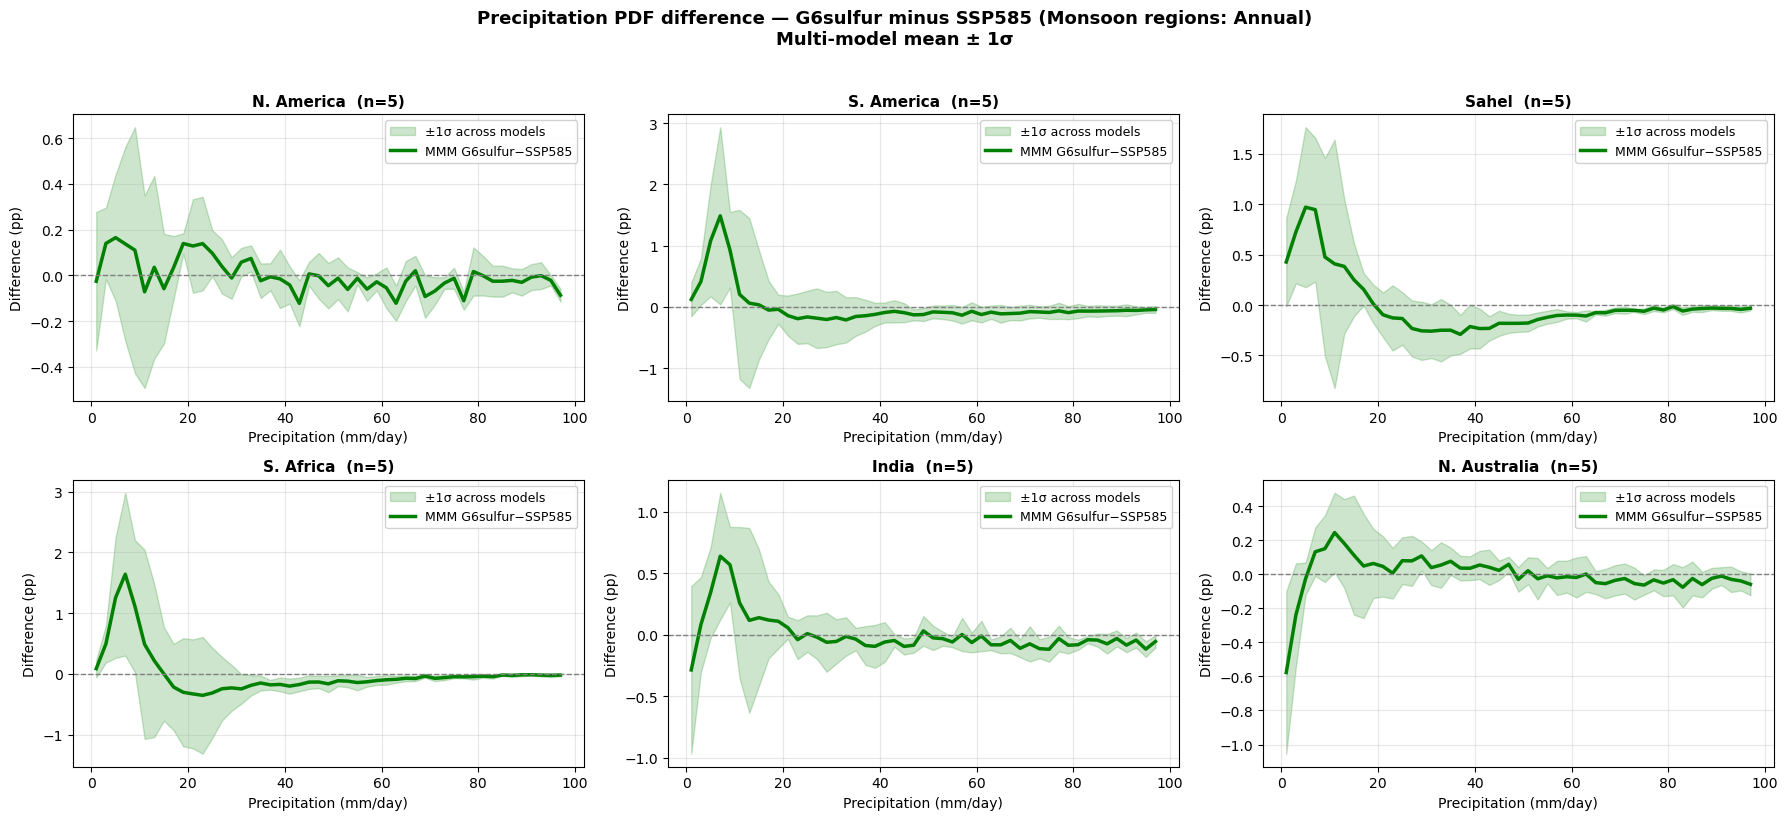

In [13]:
# All regions
plot_pdf_diff_regions(counts_all_monsoon_regions, exp1='G6sulfur', exp2='SSP585')

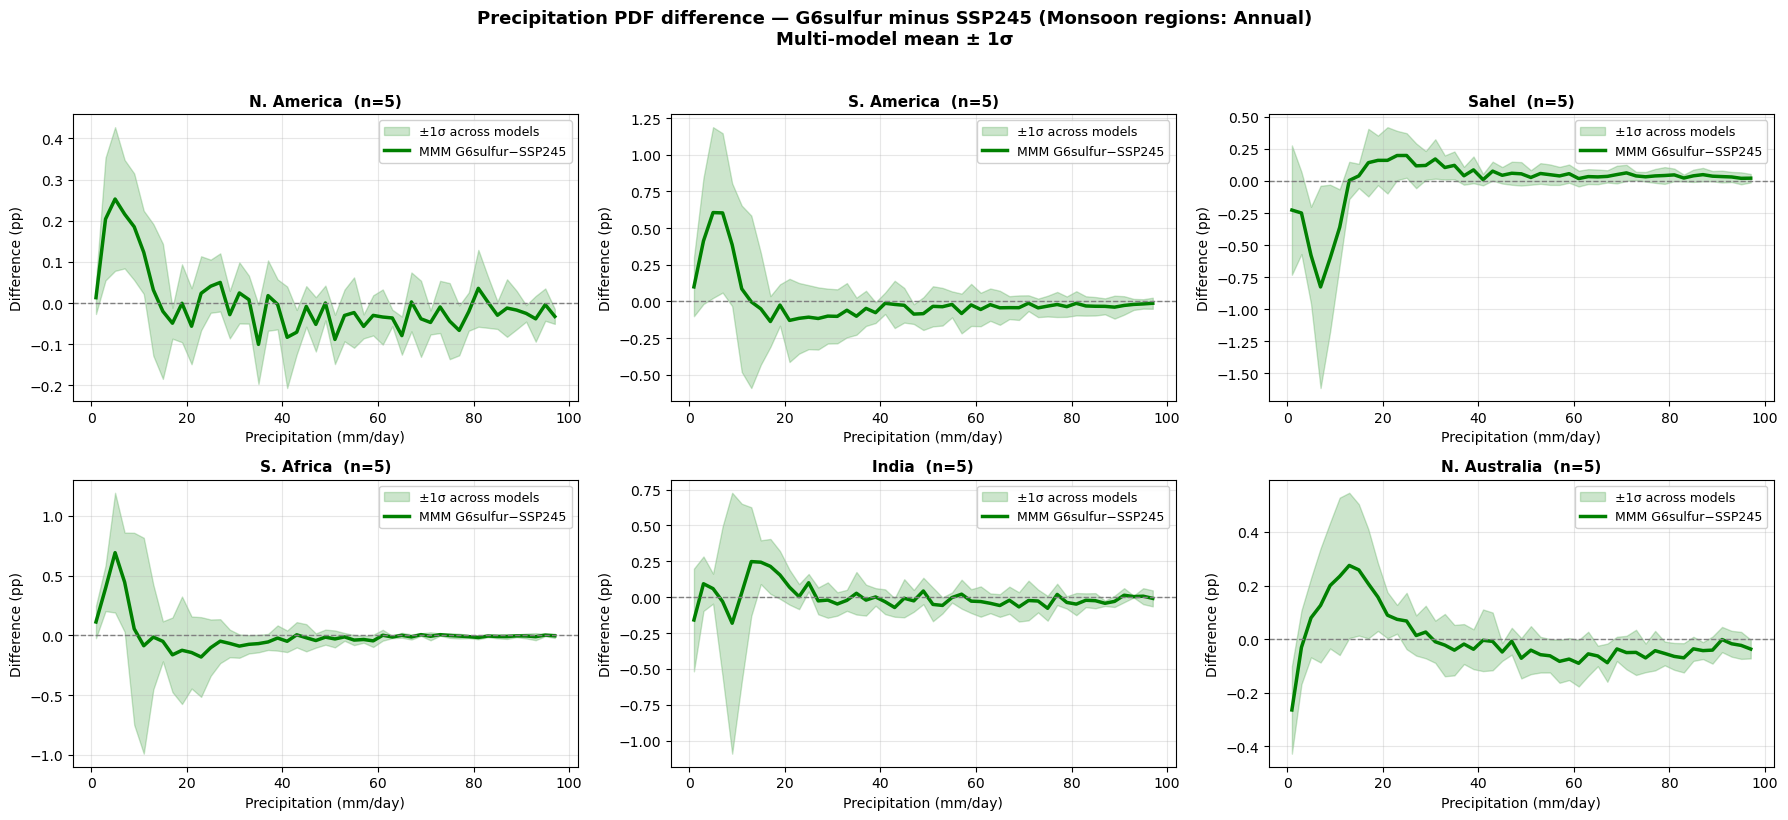

In [14]:
# All regions
plot_pdf_diff_regions(counts_all_monsoon_regions, exp1='G6sulfur', exp2='SSP245')